# Week 2 Day 5 — Exploratory Data Analysis: Correlation & Data Storytelling

## Objective

This notebook performs a complete Exploratory Data Analysis (EDA) on a real dataset.

The analysis includes:

- Descriptive statistics
- Univariate analysis
- Outlier detection and handling
- Bivariate analysis
- Correlation analysis
- Correlation heatmap
- Pairplot
- Data storytelling

The goal is to understand the structure of the dataset, identify important relationships, detect potential data issues, and communicate findings that may be useful for future machine learning modeling.

## 1. Import Libraries

We import the libraries required for data manipulation, statistical visualization, and exploratory data analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 2. Load the Dataset

The dataset is loaded into a Pandas DataFrame for further exploration and analysis.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Initial Dataset Inspection

Before performing EDA, we inspect the dataset structure, dimensions, column names, data types, and summary statistics.

In [3]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null values:")
df.info()

Dataset shape:
(1000, 8)

Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 4. Identify Numeric and Categorical Variables

Numeric variables are used for distributions, outlier detection, scatter plots, and correlation analysis.

Categorical variables are used for count plots and grouped box plots.

In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['math score', 'reading score', 'writing score']

Categorical columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 5. Descriptive Statistics

Descriptive statistics help us understand the center and spread of the numeric variables.

We examine:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [9]:
df[numeric_columns].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df[numeric_columns].median()

math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

In [11]:
df[numeric_columns].mode().iloc[0]

math score       65
reading score    72
writing score    74
Name: 0, dtype: int64

### Interpretation

The descriptive statistics provide an overview of the central tendency and spread of the numeric variables.

The mean can be strongly affected by extreme values, while the median is more robust when the data contains outliers.

The standard deviation indicates how spread out the observations are around the mean.

## 6. Univariate Analysis

Univariate analysis examines one variable at a time.

We begin by examining the distributions of the numeric variables using histograms.

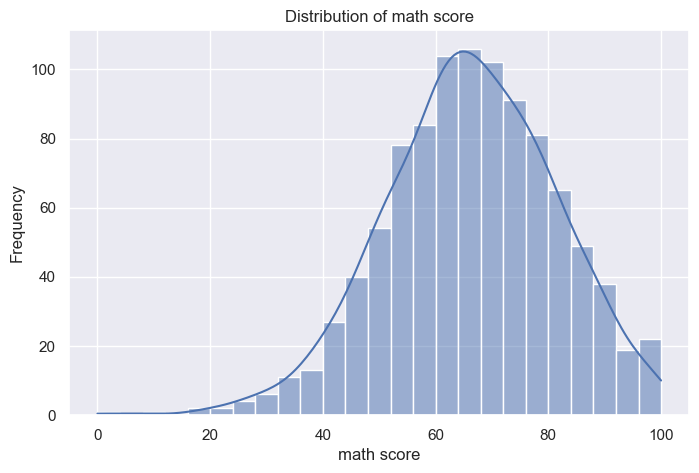

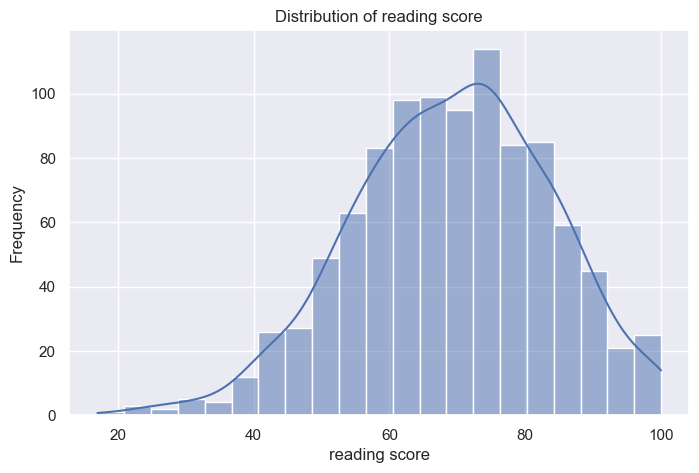

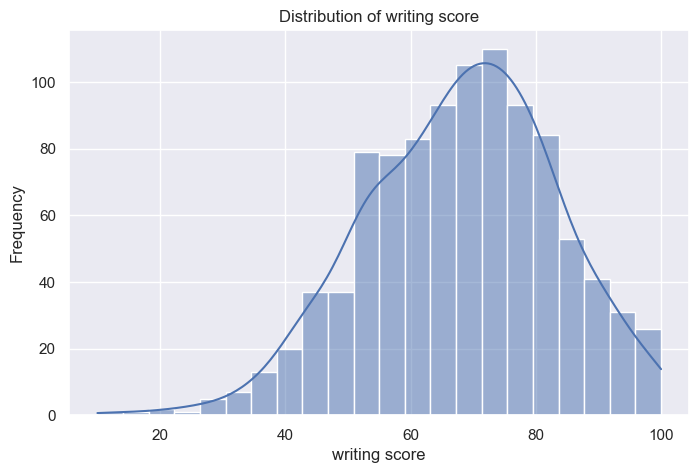

In [12]:
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Distribution Findings

The histograms show the shape and spread of the numeric variables.

The distributions should be examined for:

- Skewness
- Concentration of values
- Possible extreme values
- Unusual patterns

## 7. Box Plots

Box plots provide a visual summary of the median, quartiles, and potential outliers.

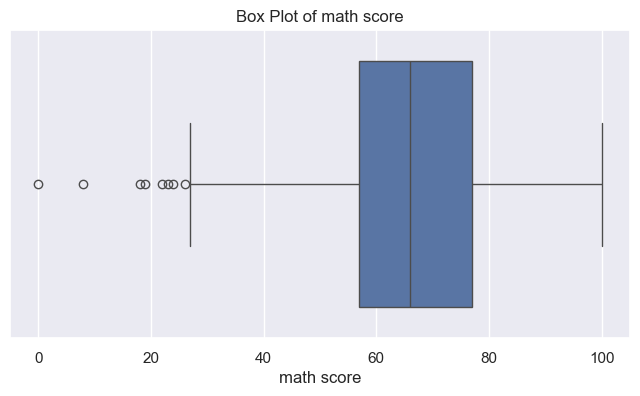

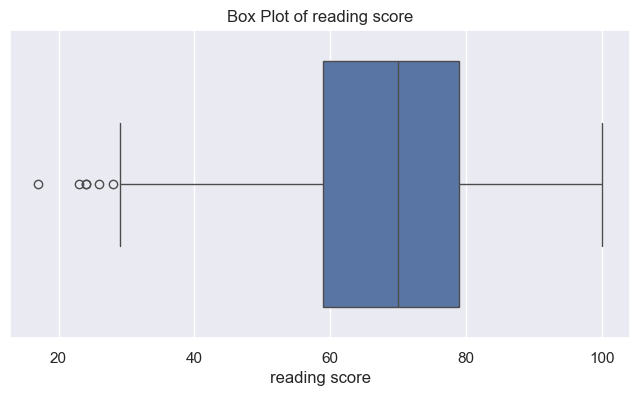

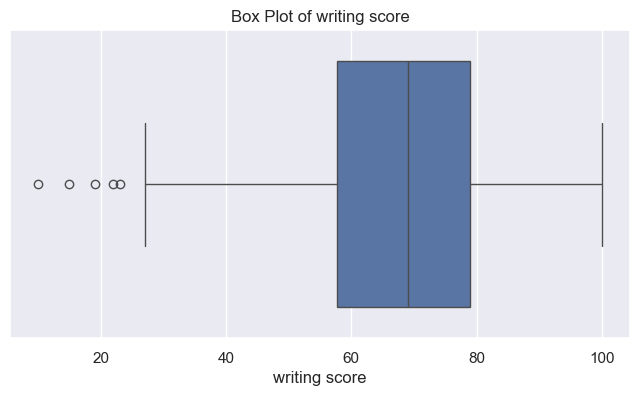

In [14]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=column)
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

## 8. Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers.

The IQR is:

IQR = Q3 - Q1

Potential outliers are values below:

Q1 - 1.5 × IQR

or above:

Q3 + 1.5 × IQR

In [15]:
outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

    print(f"{column}:")
    print(f"Q1 = {Q1}")
    print(f"Q3 = {Q3}")
    print(f"IQR = {IQR}")
    print(f"Lower Bound = {lower_bound}")
    print(f"Upper Bound = {upper_bound}")
    print(f"Number of potential outliers = {len(outliers)}")
    print("-" * 50)

math score:
Q1 = 57.0
Q3 = 77.0
IQR = 20.0
Lower Bound = 27.0
Upper Bound = 107.0
Number of potential outliers = 8
--------------------------------------------------
reading score:
Q1 = 59.0
Q3 = 79.0
IQR = 20.0
Lower Bound = 29.0
Upper Bound = 109.0
Number of potential outliers = 6
--------------------------------------------------
writing score:
Q1 = 57.75
Q3 = 79.0
IQR = 21.25
Lower Bound = 25.875
Upper Bound = 110.875
Number of potential outliers = 5
--------------------------------------------------


## Outlier Handling Decision

The detected outliers are not removed automatically.

Each potential outlier should be considered in the context of the dataset. An outlier may represent a genuine rare observation or a data-entry problem.

The decision to keep, remove, or otherwise handle an outlier should be documented and justified.

## 9. Categorical Variable Analysis

Count plots show how frequently each category appears in the dataset.

They can also reveal possible class imbalance.

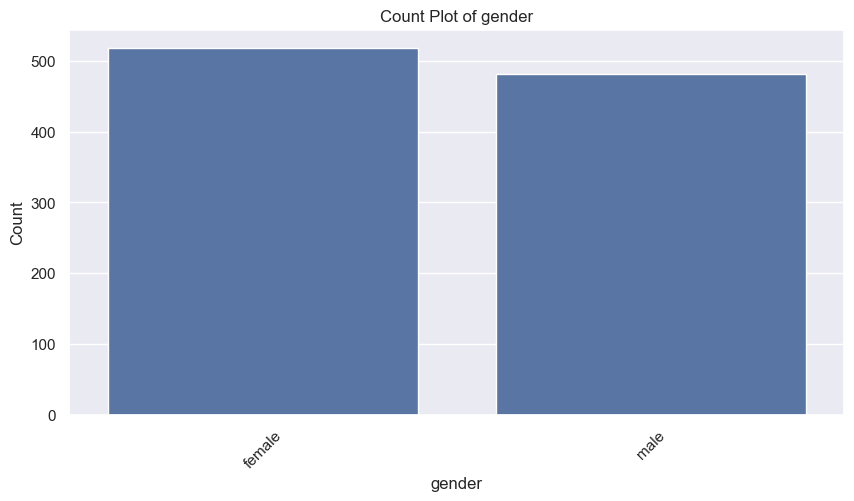

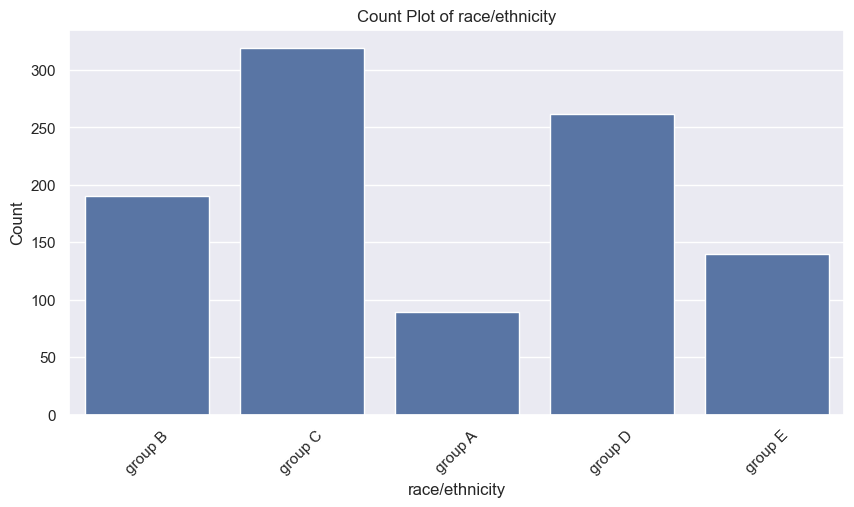

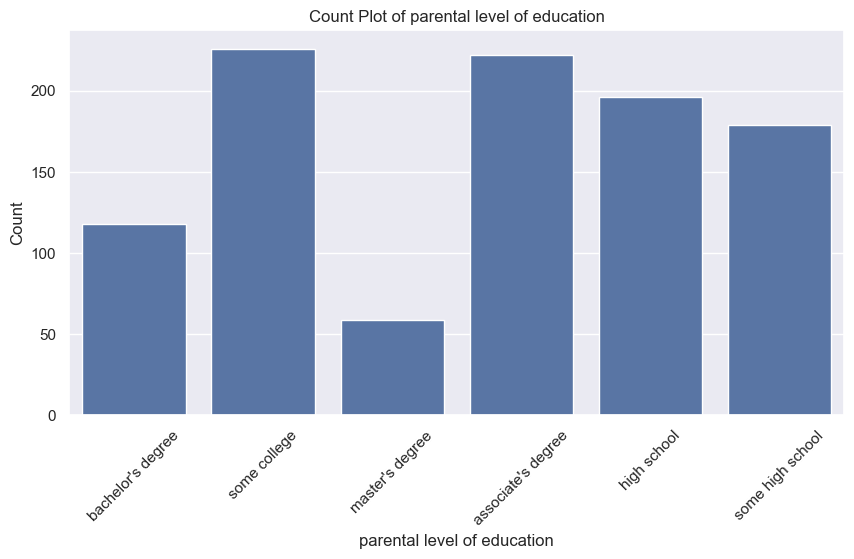

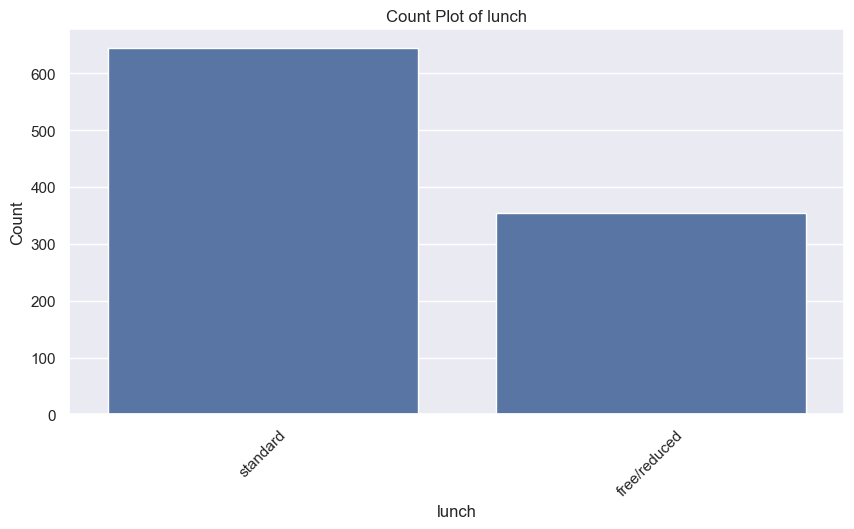

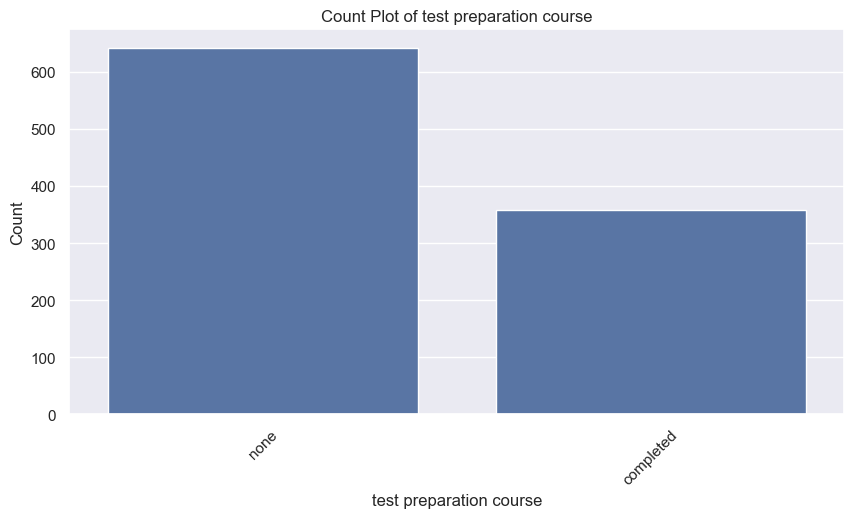

In [16]:
for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column)
    plt.title(f"Count Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

### Categorical Findings

The count plots show the frequency of observations in each category.

The distributions should be examined for:

- Dominant categories
- Rare categories
- Possible class imbalance

In [17]:
print(numeric_columns)

['math score', 'reading score', 'writing score']


In [18]:
x_column = "age"
y_column = "income"

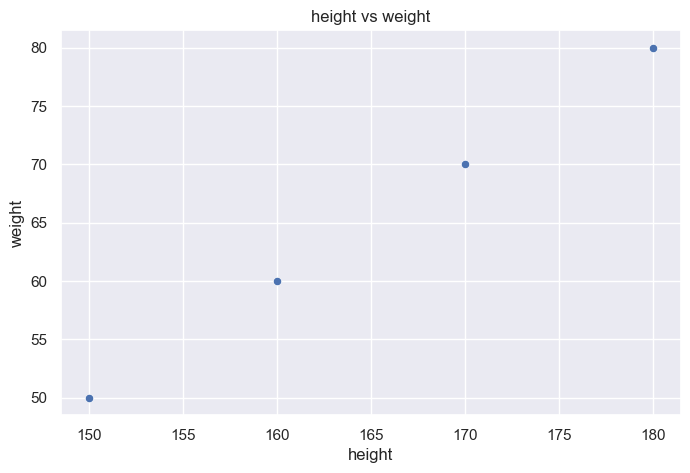

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.DataFrame({"height": [150, 160, 170, 180], "weight": [50, 60, 70, 80]})

x_column = "height"
y_column = "weight"

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x=x_column, y=y_column)

plt.title(f"{x_column} vs {y_column}")
plt.xlabel(x_column)
plt.ylabel(y_column)

plt.show()

### Bivariate Relationship

The scatter plot is used to examine the relationship between two numeric variables.

The plot should be examined for:

- Positive relationships
- Negative relationships
- Weak relationships
- Clusters
- Possible outliers

In [21]:
category_column = "category"
numeric_column = "income"

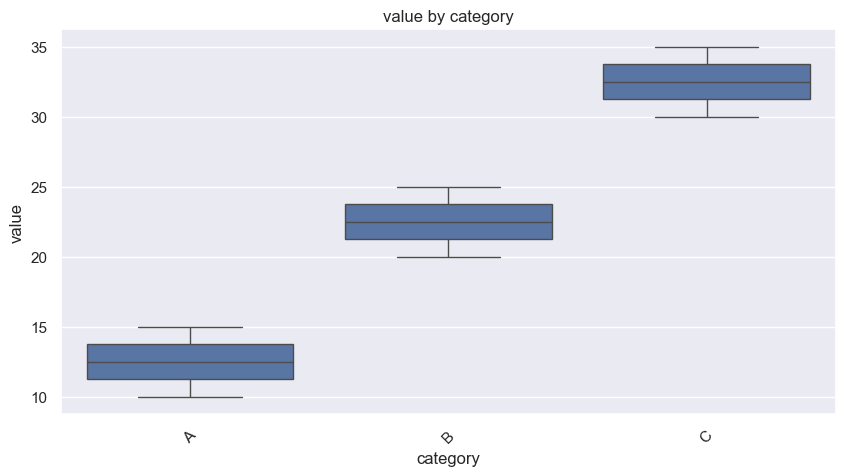

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C"],
    "value": [10, 15, 20, 25, 30, 35]
})

category_column = "category"
numeric_column = "value"

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x=category_column,
    y=numeric_column
)

plt.title(f"{numeric_column} by {category_column}")
plt.xlabel(category_column)
plt.ylabel(numeric_column)

plt.xticks(rotation=45)
plt.show()

### Grouped Box Plot Interpretation

The grouped box plot compares the distribution of a numeric variable across categories.

The chart can reveal differences in:

- Median values
- Spread
- Potential outliers
- Distribution between groups

## 10. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between two numeric variables.

The correlation coefficient ranges from:

- +1: perfect positive relationship
- 0: no linear relationship
- -1: perfect negative relationship

Correlation does not prove causation.

In [24]:
corr = df.corr(numeric_only=True)

corr

,value
value,1.0


## 11. Correlation Heatmap

The correlation heatmap visualizes the relationships between all numeric variables.

This allows us to identify the strongest positive and negative relationships in the dataset.

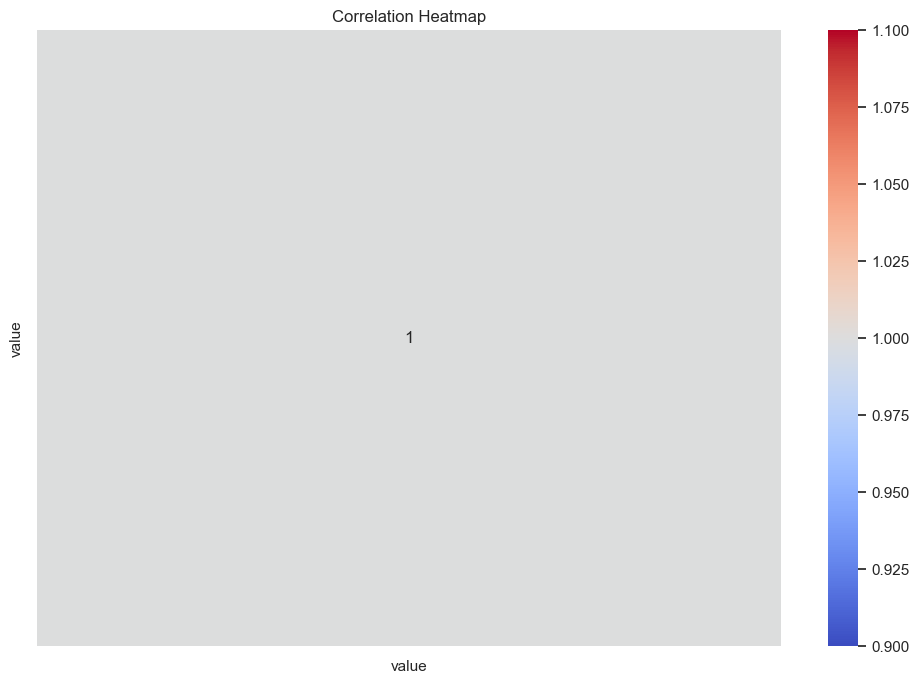

In [25]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=lambda x: abs(x),
    ascending=False
)

corr_pairs.head(10)

Series([], dtype: float64)

# 14. Data Storytelling Summary

## Dataset Overview

The dataset contains student performance records collected from standardized examinations.

The dataset contains demographic information together with three academic performance measures.

Numeric variables:

- Math Score
- Reading Score
- Writing Score

Categorical variables:

- Gender
- Race/Ethnicity
- Parental Level of Education
- Lunch
- Test Preparation Course

# 15. Conclusion

This notebook completed a full Exploratory Data Analysis of the dataset.

The analysis included:

- Descriptive statistics
- Univariate analysis
- Distribution analysis
- Outlier detection
- Outlier handling decisions
- Bivariate analysis
- Scatter plots
- Grouped box plots
- Correlation analysis
- Correlation heatmap
- Pairplot
- Data storytelling

The analysis identified important patterns, potential data issues, and relationships that may be useful for future machine learning modeling.